Wind Turbine Specifications:
Rated Power: 25KW (7.7m/s)
Cut in speed: 2.5 m/s (0.855 KW)
Cut out speed: 20 m/s (437.9 m/s)
Blade Length: 7.6m, Swept Area: 181 m2, Hub Height: 50 m

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
windspeed=pd.read_csv('windspeed.csv')
windspeed

,YEAR,MO,DY,HR,WS50M
0,2025,1,1,0,11.06
1,2025,1,1,1,10.39
2,2025,1,1,2,9.79
3,2025,1,1,3,9.70
4,2025,1,1,4,9.81
...,...,...,...,...,...
8755,2025,12,31,19,8.11
8756,2025,12,31,20,8.74
8757,2025,12,31,21,9.50
8758,2025,12,31,22,9.79


In [3]:
windspeed1=windspeed.iloc[:,4:5]
windspeed1

,WS50M
0,11.06
1,10.39
2,9.79
3,9.70
4,9.81
...,...
8755,8.11
8756,8.74
8757,9.50
8758,9.79


In [4]:
windspeed1.describe()

,WS50M
count,8760.000000
mean,7.760179
std,3.555939
min,0.210000
25%,5.290000
50%,7.510000
75%,9.782500
max,30.340000


for unit conversion,
def unit(x):
  return x/3.6 #to get m/s from kph

In [12]:
air_dens=1.275 #kg/m3
betz=0.593
s_area=181
g_eff=0.8

def wind_pow(x):
  return (0.5*air_dens*s_area*(x**3)*betz*g_eff)/1000

Wind_Power=wind_pow(windspeed1)
Wind_Power

,WS50M
0,74.057462
1,61.397415
2,51.363135
3,49.959565
4,51.678567
...,...
8755,29.198867
8756,36.545823
8757,46.932562
8758,51.363135


In [15]:
Wind_Power.rename(columns={'WS50M':'Power(KW)'},inplace=True)
Wind_Power

,Power(KW)
0,74.057462
1,61.397415
2,51.363135
3,49.959565
4,51.678567
...,...
8755,29.198867
8756,36.545823
8757,46.932562
8758,51.363135


In [11]:
Wind_Power.describe()

,Power(KW)
count,8760.000000
mean,43.775229
std,74.989371
min,0.000507
25%,8.103459
50%,23.185862
75%,51.245209
max,1528.798239


In [13]:
#wind_pow(2.5)
#wind_pow(20)

0.85530984375

In [16]:
Wind_Power.loc[(Wind_Power['Power(KW)']>=25)&(Wind_Power['Power(KW)']<437.9)]=25
Wind_Power.loc[(Wind_Power['Power(KW)']>=437.9)]=0
Wind_Power.loc[Wind_Power['Power(KW)']<=0.855]=0

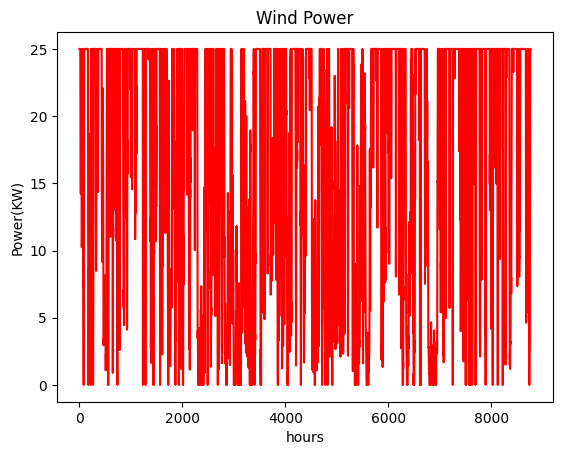

In [17]:
plt.plot(Wind_Power,c='r')
plt.xlabel('hours')
plt.ylabel('Power(KW)')
plt.title('Wind Power')
plt.show()


In [21]:
final_data=pd.concat([windspeed1,Wind_Power],axis=1)
final_data.sort_values(by='WS50M',ascending=True,ignore_index=True,inplace=True)
final_data

,WS50M,Power(KW)
0,0.21,0.0
1,0.30,0.0
2,0.32,0.0
3,0.34,0.0
4,0.35,0.0
...,...,...
8755,28.70,0.0
8756,29.55,0.0
8757,29.55,0.0
8758,29.93,0.0


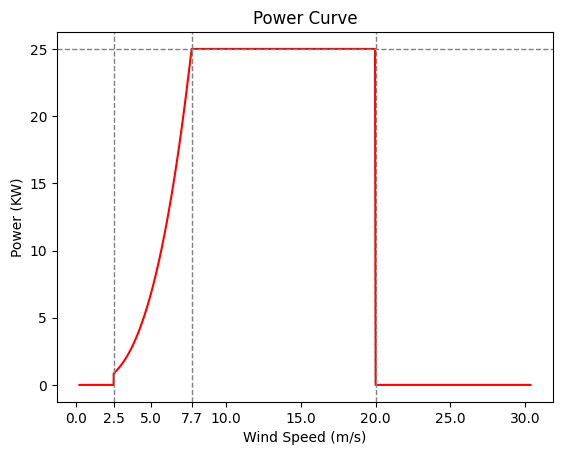

In [31]:
plt.plot(final_data['WS50M'],final_data['Power(KW)'],c='r')
plt.axvline(2.5, color='gray', linestyle='--', linewidth=1)
plt.axvline(20, color='gray', linestyle='--', linewidth=1)
plt.axvline(7.7, color='gray', linestyle='--', linewidth=1)
plt.axhline(25, color='gray', linestyle='--', linewidth=1)  # marks the spot
plt.xticks([0, 2.5,5,7.7, 10, 15, 20, 25, 30])
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Power (KW)')
plt.title('Power Curve')
plt.show()